# Precession of the Moon's rotation axis

The MEPA (Mean Earth / Polar Axis) frame used in CROISSANT is defined as `MOON_ME` frozen at a reference epoch. The Moon's rotation axis precesses around the ecliptic pole with a period of ~18.6 years and a half-angle of ~1.5 degrees. This means the MEPA Z-axis drifts away from the Moon's current rotation axis over time.

This matters because `rot_alm_z` models time evolution as a pure Z-rotation in MEPA. If the MEPA Z-axis is misaligned with the true rotation axis, the beam traces a circle around the wrong pole, introducing errors in the simulated visibilities.

**Fix:** CROISSANT defines MEPA at the observation epoch (not J2000), so the Z-axis always matches the current rotation axis. This notebook shows why that matters.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from lunarsky import MCMF, Time

%matplotlib inline

## Pole offset from J2000 over time

We measure the angular separation between the Moon's rotation axis at each epoch and its direction at J2000.

In [2]:
# MCMF z-axis = Moon's rotation axis. Track its ICRS direction over time.
pole_j2000 = SkyCoord(
    x=0,
    y=0,
    z=1,
    representation_type="cartesian",
    frame=MCMF(obstime=Time("J2000")),
).icrs


def pole_offset_deg(year):
    """Angular offset of the Moon's pole from its J2000 direction."""
    t = Time(year, format="jyear")
    pole = SkyCoord(
        x=0,
        y=0,
        z=1,
        representation_type="cartesian",
        frame=MCMF(obstime=t),
    ).icrs
    return pole.separation(pole_j2000).deg.item()


years = np.arange(2000, 2051, 0.05)
offsets = np.array([pole_offset_deg(y) for y in years])

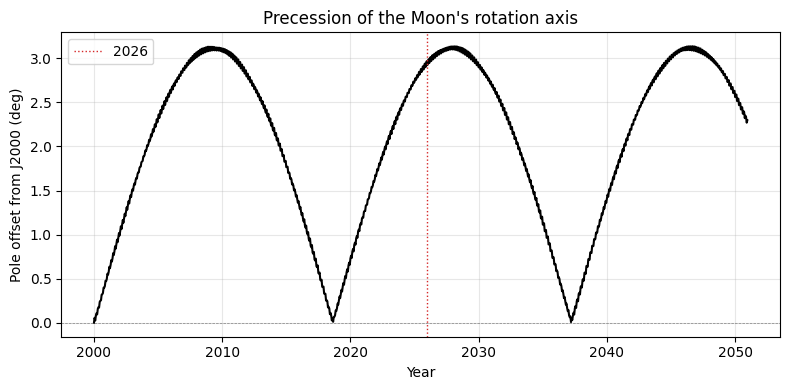

Max offset: 3.14 deg
Period: ~18.6 years
Offset at 2026: 2.92 deg


In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(years, offsets, "k-", lw=1.5)
ax.axhline(0, color="gray", ls="--", lw=0.5)
ax.axvline(2026, color="C3", ls=":", lw=1, label="2026")
ax.set_xlabel("Year")
ax.set_ylabel("Pole offset from J2000 (deg)")
ax.set_title("Precession of the Moon's rotation axis")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Max offset: {offsets.max():.2f} deg")
print("Period: ~18.6 years")
print(f"Offset at 2026: {pole_offset_deg(2026):.2f} deg")

## Pole motion during one sidereal day

Within a single simulation (~27 days), the pole barely moves. This is why `rot_alm_z` (constant-rate Z-rotation) is an excellent approximation once the MEPA epoch is set to the observation time.

In [4]:
T_sid_days = 27.32  # lunar sidereal day

sample_years = [2005, 2010, 2015, 2020, 2025, 2026, 2030]
print("Pole motion during one lunar sidereal day (~27.3 days):")
print(
    f"{'Year':>6s}  {'Start (deg)':>11s}  {'End (deg)':>11s}  {'Change (arcmin)':>15s}"
)
print("-" * 50)
for year in sample_years:
    off_start = pole_offset_deg(year)
    off_end = pole_offset_deg(year + T_sid_days / 365.25)
    change_arcmin = abs(off_end - off_start) * 60
    print(
        f"{year:6d}  {off_start:11.4f}  {off_end:11.4f}  {change_arcmin:15.2f}"
    )

Pole motion during one lunar sidereal day (~27.3 days):
  Year  Start (deg)    End (deg)  Change (arcmin)
--------------------------------------------------
  2005       2.3155       2.3427             1.63
  2010       3.0734       3.0697             0.22
  2015       1.7651       1.7328             1.94
  2020       0.7298       0.7699             2.40
  2025       2.7334       2.7522             1.13
  2026       2.9221       2.9336             0.69
  2030       2.8962       2.8839             0.74


## Summary

| Timescale | Pole motion | Impact |
|---|---|---|
| 18.6 years (full cycle) | 0 -- 3.1 deg | Maximum possible error if MEPA epoch is wrong |
| 1 year | ~1 deg | Noticeable for precision work |
| 1 sidereal day (27.3 d) | 0.2 -- 2.4 arcmin | Negligible within a single simulation |

**Conclusion:** The MEPA epoch must be set near the observation time (not J2000) to keep the Z-axis aligned with the Moon's current rotation axis. Within a single simulation, the alignment is stable to arcminute level, so `rot_alm_z` is accurate. CROISSANT handles this automatically by setting the MEPA epoch to the first observation time.